## Task 0: Setting up Ollama (1p)
a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.

b) Load the 270m parameter version of the gemma3 model and test it with any prompt.

c) Load the 4b parameter version of the gemma3 and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [2]:
!pip install openai

   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 9.0 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]

In [34]:
print("TASK 0")

# PART A
import openai 

client = openai.OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)

def test_model(model_name, prompt="explain the concept of Riemann Sum in 50 words and then briefly discribe the difference between Gemma3 270m and Gemma3 4b"):
    response = client.chat.completions.create(
        model=model_name,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.choices[0].message.content

# PART B
# 270 version:
print("========== Answer of Gemma 270m ==========\n")
print("Gemma3 270m:\n", test_model("gemma3:270m"))
print("========== END of Gemma 270m ==========\n")

# PART C
# 4b version: 
print("========== Answer of Gemma 4b ==========\n")
print("Gemma3 4b:\n", test_model("gemma3:4b"))
print("========== END of Gemma 4b ==========\n")

TASK 0
========== Answer of Gemma 270m ==========

Gemma3 270m:
 Riemann Sum is a powerful tool for solving problems involving function values. It's a summation exercise where you sum up the values of all the function's residues (the values at the poles of the function). The goal is to find the area of a region defined by the sum of the corresponding residues.   Gemma 3 270m and Gemma 3 4b are both modern versions of the Gemma library, optimized for their performance and features.

========== END of Gemma 270m ==========

========== Answer of Gemma 4b ==========

Gemma3 4b:
 Here’s an explanation of Riemann Sum and the Gemma model comparison:

**Riemann Sum:** A Riemann sum approximates the area under a curve by dividing it into thin rectangles. The area of each rectangle is its width multiplied by the function’s value at a point within that interval, summed to estimate the total area.

**Gemma Model Comparison:** Gemma 3 270M is a smaller, more efficient model, suitable for tasks need

## Task 1: Text classification with Ollama (2p)
The data/emails.csv file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [36]:
print("TASK 1")
import pandas as pd
import time

try:
    df_emails = pd.read_csv('emails.csv')
except:
    df_emails = pd.read_csv('emails.csv', sep='\t', names=['headline'], header=0)

# PART A
def classify_email(headline, model_name):
    prompt = f"Classify the email headline as 'spam', 'work', or 'unknown'. Return ONLY the word. Headline: {headline}"
    
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=0 
        )
        result = response.choices[0].message.content.strip().lower().replace(".", "")
        return result
    except Exception as e:
        return f"Error: {e}"

# PART B
df_emails['gemma_270m_base'] = df_emails['headline'].apply(lambda x: classify_email(x, "gemma3:270m"))
# PART C
df_emails['gemma_4b_base'] = df_emails['headline'].apply(lambda x: classify_email(x, "gemma3:4b"))

# PART D
print("PART D")
models = ["gemma3:270m", "gemma3:4b"]

for i in range(1, 4):
    for model in models:
        col_name = f"{model}_run_{i}"
       # print(f"  {model} - {i}th operation")
        df_emails[col_name] = df_emails['headline'].apply(lambda x: classify_email(x, model))

display(df_emails.head())

TASK 1
PART D


,headline,gemma_270m_base,gemma_4b_base,gemma3:270m_run_1,gemma3:4b_run_1,gemma3:270m_run_2,gemma3:4b_run_2,gemma3:270m_run_3,gemma3:4b_run_3
0,URGENT: Your account will be suspended within ...,suspended,spam,suspended,spam,suspended,spam,suspended,spam
1,Congratulations! You have won a 1000€ gift car...,congratulations!,spam,congratulations!,spam,congratulations!,spam,congratulations!,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam,spam,spam,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,spam,spam,spam,spam,spam,spam,spam
4,Meeting agenda for Thursday's project review,work,work,work,work,work,work,work,work


## Task 2: Sentiment analysis with Ollama (2p)
The data/news.csv file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [37]:
print("TASK 2")
import pandas as pd
import json

try:
    df_news = pd.read_csv('news.csv', sep='|', names=['headline'], header=0, engine='python')
except Exception as e:
    print(f"read fail {e}")

# PART A
def analyze_news_to_json(headline, model_name="gemma3:4b"):
    prompt = f"""
    Analyze the following financial news headline.
    1. Classify the topic: earnings, mergers, regulation, macroeconomics.
    2. Determine the sentiment: positive, negative, neutral.
    
    Return ONLY one JSON object with keys "topic" and "sentiment".
    Headline: {headline}
    """
    
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=0
        )
        content = response.choices[0].message.content.strip()
        clean_json = content.replace("```json", "").replace("```", "").strip()
        return json.loads(clean_json)
    except Exception as e:
        return {"topic": "error", "sentiment": str(e)}

# PART B
print("PART B")
parsed_results = [analyze_news_to_json(str(h), "gemma3:4b") for h in df_news['headline']]

df_analysis = pd.DataFrame(parsed_results)
df_final = pd.concat([df_news.reset_index(drop=True), df_analysis], axis=1)

display(df_final)

TASK 2
PART B


,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates...,earnings,positive
1,Helvora Pharmaceuticals misses earnings foreca...,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, ...",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in...,mergers,positive
4,Antitrust regulators block proposed merger bet...,regulation,negative
5,Kestrel Semiconductor confirms early-stage mer...,mergers,neutral
6,New EU AI Act compliance rules expected to rai...,regulation,negative
7,Finnish FSA grants Norvik Capital expanded lic...,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing press...",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Es...,macroeconomics,negative


## Task 3: Supervised machine learning (5p)
For this task, use a subset of the Bank Marketing dataset, by downloading and importing the bank-additional.csv from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

========== Basic Info ==========
(4119, 21)
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

========== Missing Values ==========
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     

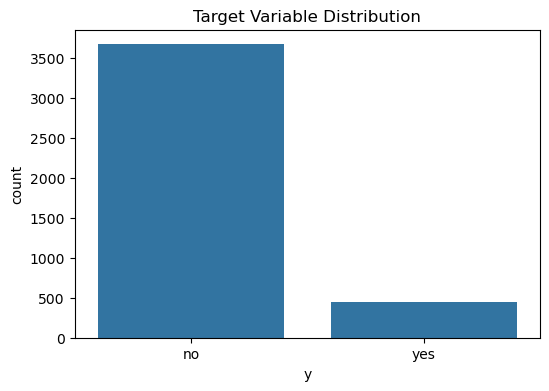

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


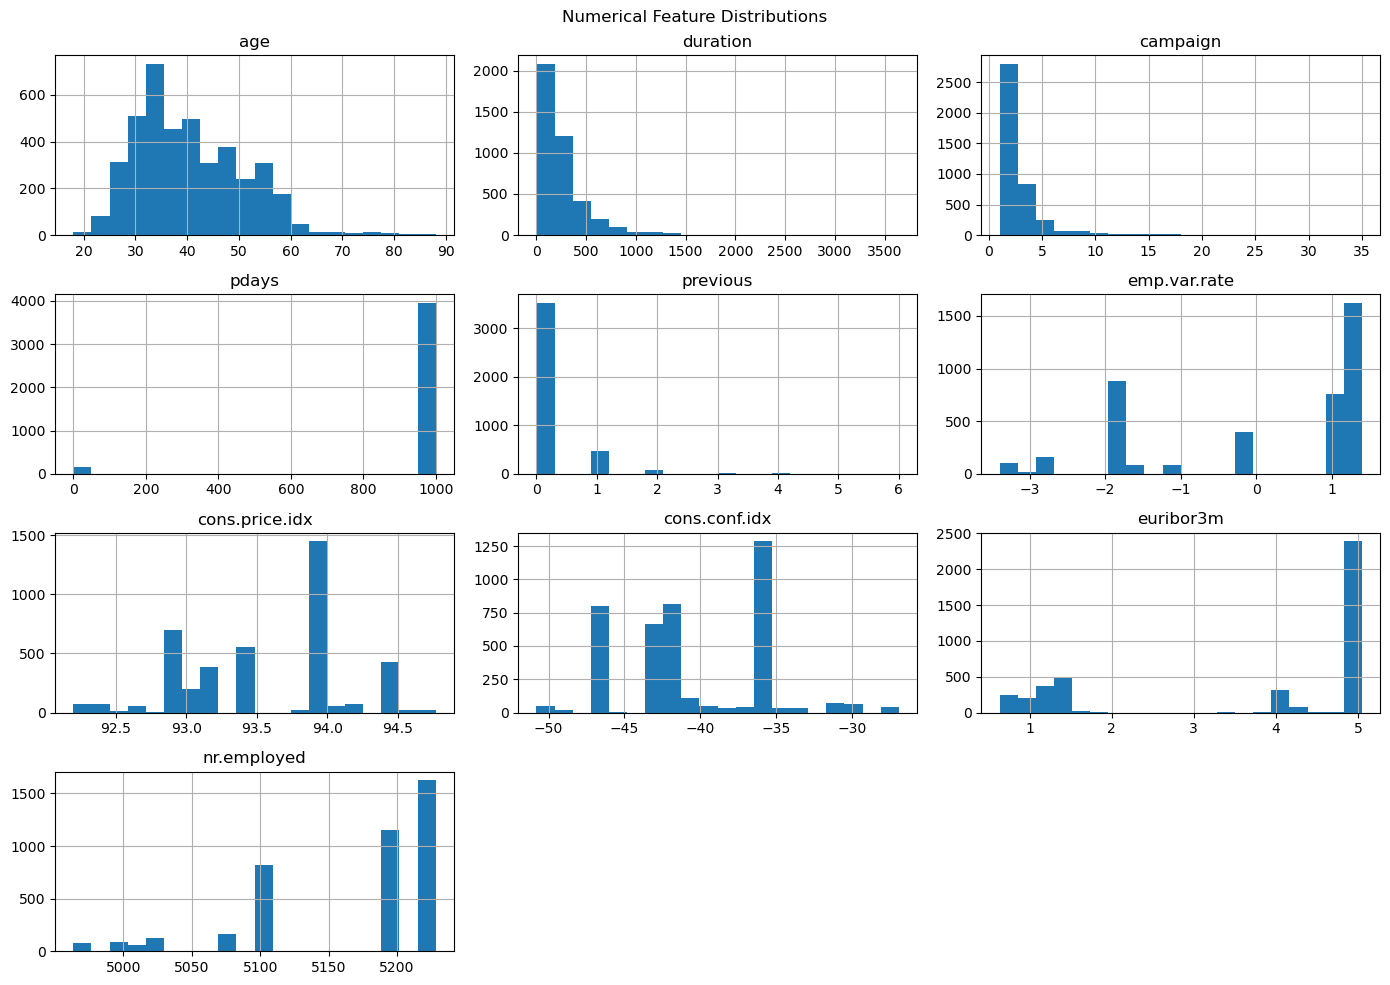

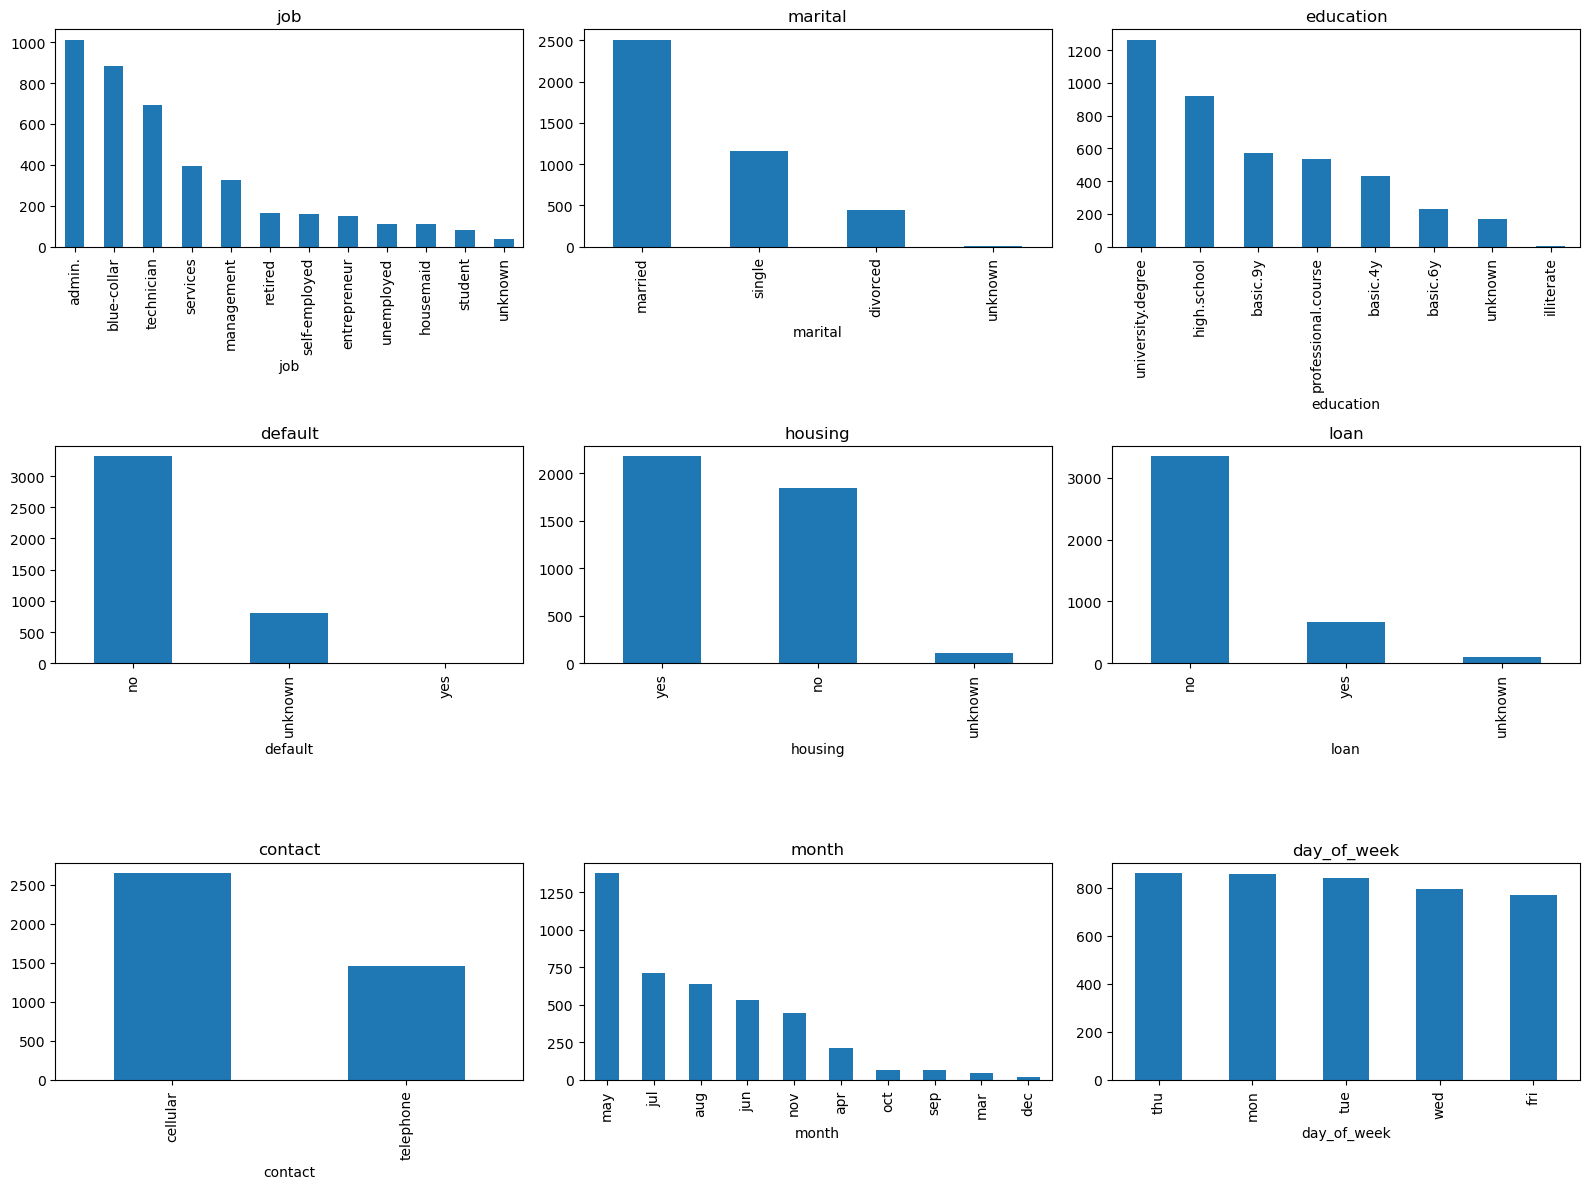

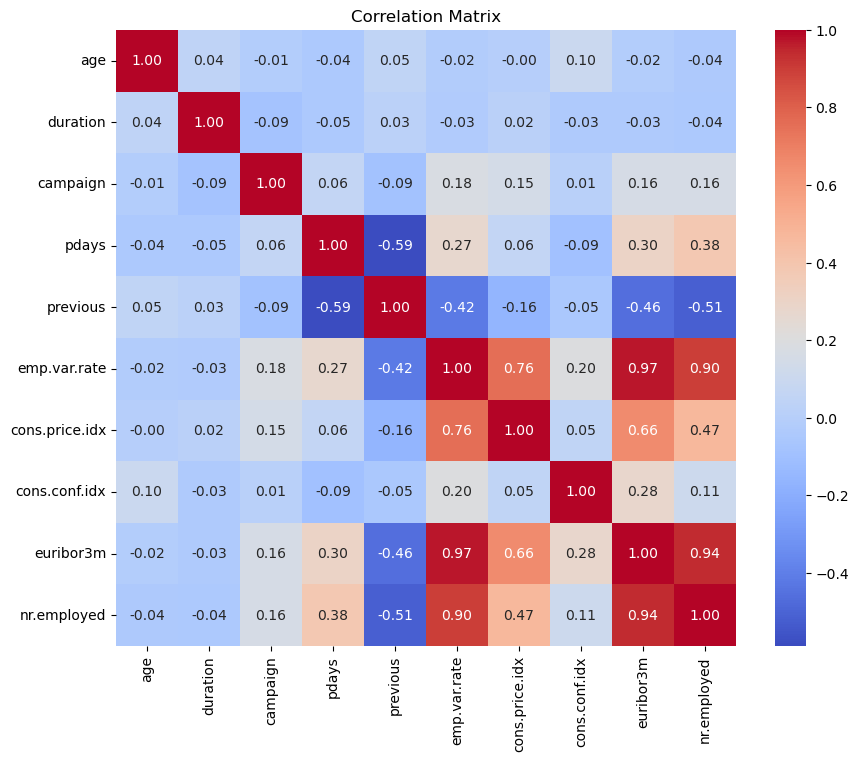


Class distribution after encoding:
y
0    3668
1     451
Name: count, dtype: int64
Imbalance ratio: 8.1:1

Split sizes → Train: 2884, Val: 617, Test: 618

[LR] Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
[LR] Val ROC AUC: 0.7999

[RF] Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
[RF] Val ROC AUC: 0.7915

[SVM] Best params: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
[SVM] Val ROC AUC: 0.7587

Logistic Regression
  Val Set AUC : 0.7999
  CV AUC      : 0.7652 ± 0.0247

Random Forest
  Val Set AUC : 0.7915
  CV AUC      : 0.7543 ± 0.0313

SVM
  Val Set AUC : 0.7587
  CV AUC      : 0.7584 ± 0.0191

Analysis:
- Cross-validation uses all training data for both training and validation,
  yielding a more stable and less biased estimate of model performance.
- A single train/val split is faster but more sensitive to the random split.
- For this dataset size (~4100 rows), CV is preferred.

FINAL TEST SET EVALUATION

 Logistic Regression 
    

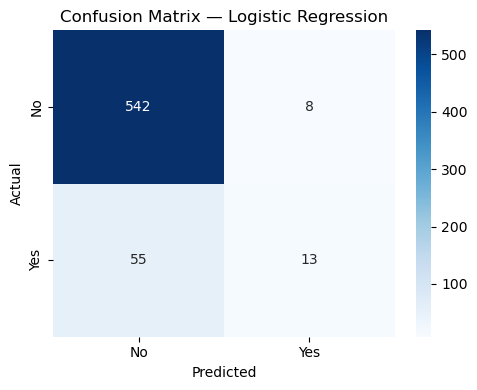


========== Model Comparison ==========
                     Accuracy  ROC AUC      F1
Logistic Regression    0.8981   0.7859  0.2921

    Conclusion:
    - This is a binary classification task with significant class imbalance
      (~89% No / ~11% Yes), making accuracy an unreliable metric.
    - ROC AUC and F1-score are therefore the primary evaluation metrics.
    - Logistic Regression achieves the best overall performance
      (ROC AUC: 0.7859, F1: 0.2921), and is selected as the best model.
    - It best balances Precision and Recall for identifying potential subscribers,
      which is critical in a marketing context where both missing subscribers (false negatives)
      and wasting resources on non-subscribers (false positives) carry real costs.
    

 Random Forest 
              precision    recall  f1-score   support

          No       0.92      0.95      0.93       550
         Yes       0.45      0.35      0.40        68

    accuracy                           0.88       

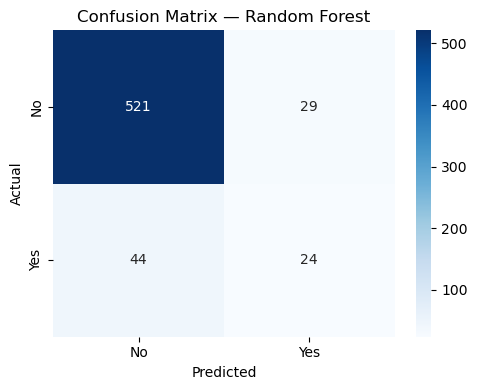


========== Model Comparison ==========
                     Accuracy  ROC AUC      F1
Logistic Regression    0.8981   0.7859  0.2921
Random Forest          0.8819   0.7498  0.3967

    Conclusion:
    - This is a binary classification task with significant class imbalance
      (~89% No / ~11% Yes), making accuracy an unreliable metric.
    - ROC AUC and F1-score are therefore the primary evaluation metrics.
    - Logistic Regression achieves the best overall performance
      (ROC AUC: 0.7859, F1: 0.2921), and is selected as the best model.
    - It best balances Precision and Recall for identifying potential subscribers,
      which is critical in a marketing context where both missing subscribers (false negatives)
      and wasting resources on non-subscribers (false positives) carry real costs.
    

 SVM 
              precision    recall  f1-score   support

          No       0.95      0.78      0.86       550
         Yes       0.27      0.65      0.38        68

    accuracy 

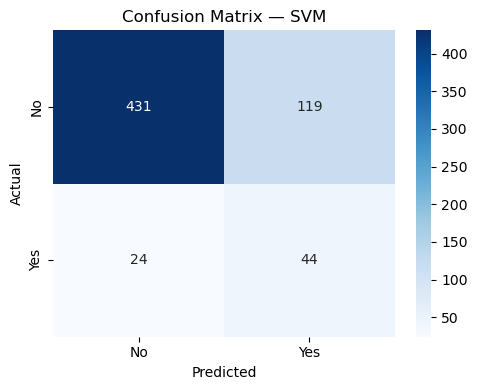


========== Model Comparison ==========
                     Accuracy  ROC AUC      F1
Logistic Regression    0.8981   0.7859  0.2921
Random Forest          0.8819   0.7498  0.3967
SVM                    0.7686   0.7696  0.3810

    Conclusion:
    - This is a binary classification task with significant class imbalance
      (~89% No / ~11% Yes), making accuracy an unreliable metric.
    - ROC AUC and F1-score are therefore the primary evaluation metrics.
    - Logistic Regression achieves the best overall performance
      (ROC AUC: 0.7859, F1: 0.2921), and is selected as the best model.
    - It best balances Precision and Recall for identifying potential subscribers,
      which is critical in a marketing context where both missing subscribers (false negatives)
      and wasting resources on non-subscribers (false positives) carry real costs.
    


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

# PART A
df_bank = pd.read_csv('bank-additional.csv', sep=';')

print("========== Basic Info ==========")
print(df_bank.shape)
print(df_bank.dtypes)
print("\n========== Missing Values ==========")
print(df_bank.isnull().sum())
print("\n========== Descriptive Statistics ==========")
print(df_bank.describe())

# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='y', data=df_bank)
plt.title('Target Variable Distribution')
plt.show()
print(df_bank['y'].value_counts(normalize=True))
num_cols = df_bank.select_dtypes(include=np.number).columns
df_bank[num_cols].hist(figsize=(14, 10), bins=20)
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()
cat_cols = df_bank.select_dtypes(include='object').columns.drop('y')
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, cat_cols):
    df_bank[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 8))
sns.heatmap(df_bank[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# PART B
df_processed = df_bank.drop(columns=['duration'])
le = LabelEncoder()
df_processed['y'] = le.fit_transform(df_processed['y'])
df_final = pd.get_dummies(df_processed, drop_first=True)
X = df_final.drop('y', axis=1)
y = df_final['y']
print(f"\nClass distribution after encoding:\n{y.value_counts()}")
print(f"Imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.1f}:1")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=42, stratify=y_train_val)

print(f"\nSplit sizes → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

scaler = StandardScaler()
X_train_s     = scaler.fit_transform(X_train)
X_val_s       = scaler.transform(X_val)
X_test_s      = scaler.transform(X_test)
X_train_val_s = scaler.transform(X_train_val) 

# PART C
#regression 
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr,
                       cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_s, y_train)
best_lr = grid_lr.best_estimator_
print(f"\n[LR] Best params: {grid_lr.best_params_}")
print(f"[LR] Val ROC AUC: {roc_auc_score(y_val, best_lr.predict_proba(X_val_s)[:,1]):.4f}")

# Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'),
                       param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_s, y_train)
best_rf = grid_rf.best_estimator_
print(f"\n[RF] Best params: {grid_rf.best_params_}")
print(f"[RF] Val ROC AUC: {roc_auc_score(y_val, best_rf.predict_proba(X_val_s)[:,1]):.4f}")

# SVM 
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
grid_svm = GridSearchCV(SVC(probability=True, random_state=42, class_weight='balanced'),
                        param_grid_svm, cv=5, scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train_s, y_train)
best_svm = grid_svm.best_estimator_
print(f"\n[SVM] Best params: {grid_svm.best_params_}")
print(f"[SVM] Val ROC AUC: {roc_auc_score(y_val, best_svm.predict_proba(X_val_s)[:,1]):.4f}")

# PART D
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in [('Logistic Regression', best_lr),
                    ('Random Forest', best_rf),
                    ('SVM', best_svm)]:
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_s)[:,1])
    cv_aucs = cross_val_score(model, X_train_val_s, y_train_val,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    results[name] = {'val_auc': val_auc, 'cv_mean': cv_aucs.mean(), 'cv_std': cv_aucs.std()}
    print(f"\n{name}")
    print(f"  Val Set AUC : {val_auc:.4f}")
    print(f"  CV AUC      : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")

print("""
Analysis:
- Cross-validation uses all training data for both training and validation,
  yielding a more stable and less biased estimate of model performance.
- A single train/val split is faster but more sensitive to the random split.
- For this dataset size (~4100 rows), CV is preferred.
""")

# PART E
print("====================")
print("FINAL TEST SET EVALUATION")
print("====================")

metrics_summary = {}
for name, model in [('Logistic Regression', best_lr),
                    ('Random Forest', best_rf),
                    ('SVM', best_svm)]:
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred)
    metrics_summary[name] = {'Accuracy': acc, 'ROC AUC': auc, 'F1': f1}

    print(f"\n {name} ")
    print(classification_report(y_test, y_pred, target_names=['No', 'Yes']))
    print(f"ROC AUC: {auc:.4f}")

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout(); plt.show()

    summary_df = pd.DataFrame(metrics_summary).T
    print("\n========== Model Comparison ==========")
    print(summary_df.round(4))
    best_model_name = summary_df['ROC AUC'].idxmax()
    best_auc = summary_df.loc[best_model_name, 'ROC AUC']
    best_f1  = summary_df.loc[best_model_name, 'F1']
    print(f"""
    Conclusion:
    - This is a binary classification task with significant class imbalance
      (~89% No / ~11% Yes), making accuracy an unreliable metric.
    - ROC AUC and F1-score are therefore the primary evaluation metrics.
    - {best_model_name} achieves the best overall performance
      (ROC AUC: {best_auc:.4f}, F1: {best_f1:.4f}), and is selected as the best model.
    - It best balances Precision and Recall for identifying potential subscribers,
      which is critical in a marketing context where both missing subscribers (false negatives)
      and wasting resources on non-subscribers (false positives) carry real costs.
    """)